In [118]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import pandas as pd
import colorsys
from functools import lru_cache

In [119]:
# (((xref:interpro-IPR016054 OR xref:interpro-IPR026110 OR xref:interpro-IPR026524 OR xref:interpro-IPR031424 OR xref:interpro-IPR038773 OR xref:interpro-IPR039457 OR xref:interpro-IPR039237 OR xref:interpro-IPR042339 OR xref:interpro-IPR051445 OR xref:interpro-IPR035076 OR xref:interpro-IPR003571 OR xref:interpro-IPR045860) AND fragment:false) OR (accession:I6R1R5 OR accession:P0DPX5 OR accession:P0DPX9 OR accession:P0DPY0 OR accession:P0DPY1 OR accession:P0DPX7 OR accession:P0DPX8 OR accession:P0DPX6 OR accession:P0DPU8)) AND (taxonomy_id:33208)

In [120]:
df = pd.read_csv("../../data/raw/data_for_tree/clusters_70id_reassign.tsv", sep='\t', header=None, names=["rep", "member"])
df["protein_id"] = np.where(
    df["member"].str.contains("Centipede", case=False, na=False),
    df["member"],
    df["member"].str.split("_").str[0]
)
df

,rep,member,protein_id
0,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981
1,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981
2,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703
3,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872
4,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641
...,...,...,...
58182,P0DPX5_IPR045860_1_24-107,I6R1R5_IPR045860_1_24-110,I6R1R5
58183,P0DPX5_IPR045860_1_24-107,I6RA69_IPR045860_1_24-110,I6RA69
58184,Q8T8C6_IPR045860_1_13-112,Q8T8C6_IPR045860_1_13-112,Q8T8C6
58185,R7UXY0_IPR045860_1_94-150,R7UXY0_IPR045860_1_94-150,R7UXY0


In [121]:
df[df["member"].str.split("_").str[0] == "A0A9D1E7W6"]

,rep,member,protein_id


In [122]:
from Bio import SeqIO

# --- Normalization function ---
def normalize_id(seq_id: str) -> str:
    if "Centipede" in seq_id:
        return seq_id
    return seq_id.split("_")[0]

def normalize_id_uniprotfasta(seq_id: str) -> str:
    if "Centipede" in seq_id:
        return seq_id
    return seq_id.split("|")[1]
# --- 1. FASTA used for clustering --- (based on data for clustering)
fasta1_file = "/Users/selin/PycharmProjects/3FTx_novel_taxa/data/interm/merged/dataset_for_cluster.fasta"
fasta1_ids = {normalize_id(rec.id) for rec in SeqIO.parse(fasta1_file, "fasta")}
print(f"FASTA1 (cluster input) IDs: {len(fasta1_ids)}")

# --- 2. Cluster TSV members --- (based on data for clustering)
member_ids = {normalize_id(m) for m in df["member"].astype(str)}
print(f"Cluster TSV member IDs: {len(member_ids)}")

# --- 3. Metadata --- (merged from interpro directories)
metadata = pd.read_csv("../../data/interm/merged/merged_with_lineage.csv")
metadata_ids = set(metadata["protein_id"].astype(str))
print(f"Metadata protein IDs: {len(metadata_ids)}")

# --- 4. Second FASTA  --- (merged from interpro directories)
fasta2_file = "../../data/interm/merged/sequences.fasta"
fasta2_ids = {normalize_id_uniprotfasta(rec.id) for rec in SeqIO.parse(fasta2_file, "fasta")}
print(f"FASTA2 (sequences.fasta) IDs: {len(fasta2_ids)}")

# --- Pairwise comparisons ---
def compare_sets(name_a, ids_a, name_b, ids_b, n=10):
    extra = ids_a - ids_b
    missing = ids_b - ids_a
    print(f"\n### {name_a} vs {name_b} ###")
    print(f"Extra in {name_a} but not in {name_b}: {len(extra)}")
    print(f"Extra in {name_b} but not in {name_a}: {len(missing)}")
    if extra:
        print("Examples extra:", list(extra)[:n])
    if missing:
        print("Examples missing:", list(missing)[:n])

#compare_sets("FASTA1", fasta1_ids, "TSV", member_ids)
compare_sets("FASTA1", fasta1_ids, "Metadata", metadata_ids)
#compare_sets("FASTA1", fasta1_ids, "FASTA2", fasta2_ids)
#compare_sets("TSV", member_ids, "Metadata", metadata_ids)
#compare_sets("TSV", member_ids, "FASTA2", fasta2_ids)
#compare_sets("Metadata", metadata_ids, "FASTA2", fasta2_ids)


FASTA1 (cluster input) IDs: 52067
Cluster TSV member IDs: 52067
Metadata protein IDs: 52829
FASTA2 (sequences.fasta) IDs: 52829

### FASTA1 vs Metadata ###
Extra in FASTA1 but not in Metadata: 148
Extra in Metadata but not in FASTA1: 910
Examples extra: ['Centipede3FTx_0033_61981', 'Centipede3FTx_0092_984703', 'Centipede3FTx_0115_984703', 'Centipede3FTx_0080_61981', 'Centipede3FTx_0036_60158', 'Centipede3FTx_0123_60158', 'Centipede3FTx_0001_61981', 'Centipede3FTx_0126_60158', 'Centipede3FTx_0013_1255758', 'Centipede3FTx_0140_1255758']
Examples missing: ['A0A182TW55', 'A0A151X230', 'A0A2K5NXF1', 'A0A087QQZ9', 'Q6PBG1', 'A0A9J7H3G5', 'A0A836EPP3', 'A0AAD5B061', 'A0A8C6W3Y0', 'A0A852ARA8']


In [123]:
rep_to_cluster = {rep: i for i, rep in enumerate(sorted(df["rep"].unique()))}
df["cluster_id"] = df["rep"].map(rep_to_cluster)
df

,rep,member,protein_id,cluster_id
0,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,11103
1,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,11130
2,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,11180
3,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872,4329
4,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641,8912
...,...,...,...,...
58182,P0DPX5_IPR045860_1_24-107,I6R1R5_IPR045860_1_24-110,I6R1R5,11708
58183,P0DPX5_IPR045860_1_24-107,I6RA69_IPR045860_1_24-110,I6RA69,11708
58184,Q8T8C6_IPR045860_1_13-112,Q8T8C6_IPR045860_1_13-112,Q8T8C6,11854
58185,R7UXY0_IPR045860_1_94-150,R7UXY0_IPR045860_1_94-150,R7UXY0,11951


In [124]:
# Count how many members each cluster has
df["cluster_id"].value_counts()

cluster_id
5469     1337
2351      830
1690      681
11454     665
8573      653
         ... 
1508        1
11728       1
11523       1
11244       1
12028       1
Name: count, Length: 12188, dtype: int64

In [125]:
metadata = pd.read_csv("../../data/interm/merged/merged_with_lineage.csv")
metadata

,protein_id,protein_name,organism,sequence_length,tax_id,interpro_1,interpro_2,interpro_3,interpro_4,kingdom,phylum,class,order,family,genus
0,A0A016RUD2,Activin types I and II receptor domain-contain...,Ancylostoma ceylanicum,102,53326.0,IPR045860,NaN,NaN,NaN,Metazoa,Nematoda,Chromadorea,Rhabditida,Ancylostomatidae,Ancylostoma
1,A0A016SEB0,UPAR/Ly6 domain-containing protein qvr,Ancylostoma ceylanicum,160,53326.0,IPR031424,NaN,NaN,NaN,Metazoa,Nematoda,Chromadorea,Rhabditida,Ancylostomatidae,Ancylostoma
2,A0A016SHP2,Protein quiver,Ancylostoma ceylanicum,171,53326.0,IPR031424,NaN,NaN,NaN,Metazoa,Nematoda,Chromadorea,Rhabditida,Ancylostomatidae,Ancylostoma
3,A0A016SK76,UPAR/Ly6 domain-containing protein,Ancylostoma ceylanicum,685,53326.0,IPR045860,NaN,NaN,NaN,Metazoa,Nematoda,Chromadorea,Rhabditida,Ancylostomatidae,Ancylostoma
4,A0A016SKC5,Mos1 transposase HTH domain-containing protein,Ancylostoma ceylanicum,755,53326.0,IPR045860,NaN,NaN,NaN,Metazoa,Nematoda,Chromadorea,Rhabditida,Ancylostomatidae,Ancylostoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52824,X1WGJ5,UPAR/Ly6 domain-containing protein,Danio rerio (Zebrafish),126,7955.0,IPR016054,IPR045860,NaN,NaN,Metazoa,Chordata,Actinopteri,Cypriniformes,Danionidae,Danio
52825,X1YV74,Serine/threonine-protein kinase receptor,Capitella teleta,488,283909.0,IPR045860,NaN,NaN,NaN,Metazoa,Annelida,Polychaeta,NaN,Capitellidae,Capitella
52826,X2ACF0,Protein sleepless,Capitella teleta (Polychaete worm),106,283909.0,IPR031424,NaN,NaN,NaN,Metazoa,Annelida,Polychaeta,NaN,Capitellidae,Capitella
52827,X2ATT7,Snake toxin/toxin-like domain-containing protein,Capitella teleta,157,283909.0,IPR045860,NaN,NaN,NaN,Metazoa,Annelida,Polychaeta,NaN,Capitellidae,Capitella


In [126]:
metadata["kingdom"].value_counts()

kingdom
Metazoa           52788
Viridiplantae        10
Heunggongvirae        4
Bacillati             2
Name: count, dtype: int64

In [127]:
df_merged = df.merge(
    metadata,
    on="protein_id",
    how="left",
    validate="many_to_one"  # optional guard; remove if you don't want checks
)
df_merged

,rep,member,protein_id,cluster_id,protein_name,organism,sequence_length,tax_id,interpro_1,interpro_2,interpro_3,interpro_4,kingdom,phylum,class,order,family,genus
0,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,11103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,11130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,11180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872,4329,UPAR/Ly6 domain-containing protein,Diceros bicornis minor (South-central black rh...,139.0,77932.0,IPR016054,IPR035076,IPR042339,IPR045860,Metazoa,Chordata,Mammalia,Perissodactyla,Rhinocerotidae,Diceros
4,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641,8912,UPAR/Ly6 domain-containing protein,Ovis ammon polii,401.0,230172.0,IPR016054,IPR035076,IPR042339,IPR045860,Metazoa,Chordata,Mammalia,Artiodactyla,Bovidae,Ovis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58182,P0DPX5_IPR045860_1_24-107,I6R1R5_IPR045860_1_24-110,I6R1R5,11708,Omega-scoloptoxin(05)-Ssm1a,Scolopendra mutilans,129.0,2836329.0,IPR045860,NaN,NaN,NaN,Metazoa,Arthropoda,Chilopoda,Scolopendromorpha,Scolopendridae,Scolopendra
58183,P0DPX5_IPR045860_1_24-107,I6RA69_IPR045860_1_24-110,I6RA69,11708,Putative Ca2+ channel activator,Scolopendra subspinipes,136.0,55038.0,IPR045860,NaN,NaN,NaN,Metazoa,Arthropoda,Chilopoda,Scolopendromorpha,Scolopendridae,Scolopendra
58184,Q8T8C6_IPR045860_1_13-112,Q8T8C6_IPR045860_1_13-112,Q8T8C6,11854,Serine/threonine-protein kinase receptor,Halocynthia roretzi,591.0,7729.0,IPR045860,NaN,NaN,NaN,Metazoa,Chordata,Ascidiacea,Stolidobranchia,Pyuridae,Halocynthia
58185,R7UXY0_IPR045860_1_94-150,R7UXY0_IPR045860_1_94-150,R7UXY0,11951,UPAR/Ly6 domain-containing protein,Capitella teleta,177.0,283909.0,IPR045860,NaN,NaN,NaN,Metazoa,Annelida,Polychaeta,NaN,Capitellidae,Capitella


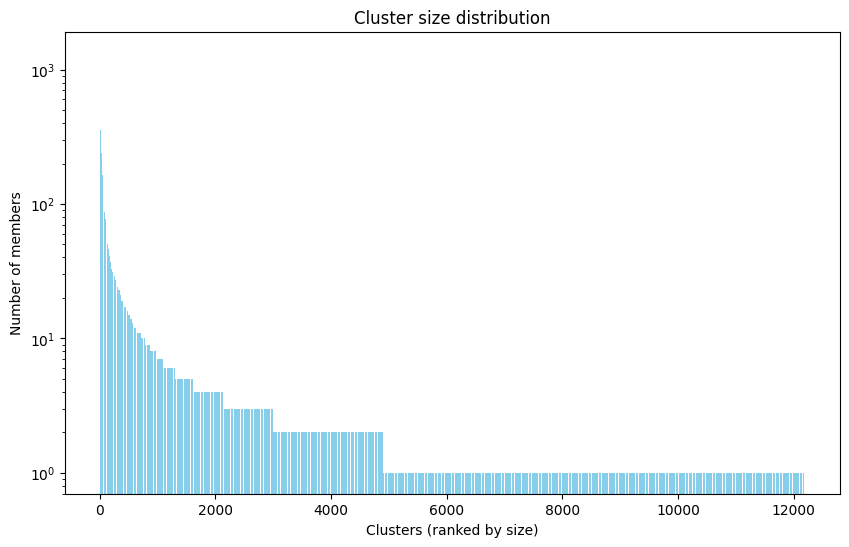

In [128]:
# count members per cluster and sort descending
cluster_sizes = df_merged.groupby("cluster_id")["member"].count().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(range(len(cluster_sizes)), cluster_sizes.values, color='skyblue')
plt.xlabel("Clusters (ranked by size)")
plt.ylabel("Number of members")
plt.yscale('log')
plt.title("Cluster size distribution")
plt.show()

In [129]:
df_merged[df_merged['cluster_id'] == 11224].groupby('kingdom').size()


kingdom
Metazoa    1
dtype: int64

In [130]:
taxonomy_cols = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus']

# Get top 100 clusters by member count
top_clusters = df_merged['cluster_id'].value_counts().head(100).index
df_top = df_merged[df_merged['cluster_id'].isin(top_clusters)]

# Compute homogeneity percentages per cluster
homogeneity_top = {}
for col in taxonomy_cols:
    ct = pd.crosstab(df_top['cluster_id'], df_top[col], normalize='index') * 100
    homogeneity_top[col] = ct.round(1)  # round to 1 decimal

# Example: check top cluster phylum composition
print(homogeneity_top['class'])


class       Actinopteri  Amphibia   Aves  Bivalvia  Chondrichthyes  Cladistia  \
cluster_id                                                                      
105                 0.0       0.0  100.0       0.0             0.0        0.0   
468               100.0       0.0    0.0       0.0             0.0        0.0   
486                 0.0       0.0  100.0       0.0             0.0        0.0   
766               100.0       0.0    0.0       0.0             0.0        0.0   
776               100.0       0.0    0.0       0.0             0.0        0.0   
...                 ...       ...    ...       ...             ...        ...   
11702               0.0       0.0    0.0       0.0             0.0        0.0   
11830               0.0       0.0    0.0       0.0             0.0        0.0   
11891              68.8      12.5   18.8       0.0             0.0        0.0   
12127               0.0       1.0    1.0       0.0             0.0        0.0   
12166              98.2     

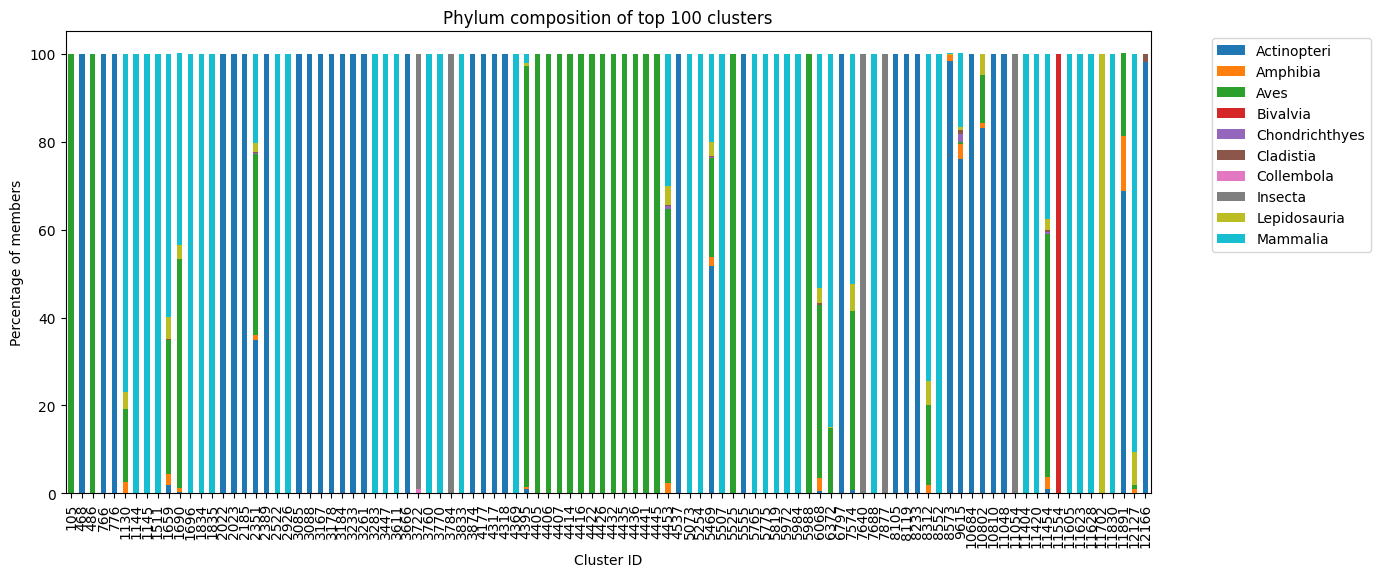

In [131]:
homogeneity_top['class'].plot(kind='bar', stacked=True, figsize=(14,6))
plt.ylabel("Percentage of members")
plt.xlabel("Cluster ID")
plt.title("Phylum composition of top 100 clusters")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [132]:
df_merged["kingdom"].value_counts()

kingdom
Metazoa           58004
Viridiplantae         5
Heunggongvirae        4
Name: count, dtype: int64

In [136]:


# df_merged must exist with:
# ['cluster_id','kingdom','phylum','class','order','family','genus', ...]
# and an ID column for counting samples:
id_col = 'protein_id' if 'protein_id' in df_merged.columns else 'member'

taxonomy_cols = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus']

# -------------------------- LCA per cluster ----------------------------------
def lca_for_group(g: pd.DataFrame, tax_cols):
    lca_rank, lca_value = 'Mixed', 'Mixed'
    for col in tax_cols:
        vals = g[col].dropna().unique()
        if len(vals) == 0:
            break
        if len(vals) == 1:
            lca_rank, lca_value = col, vals[0]
        else:
            break
    return lca_rank, lca_value

lca_rows = []
for cid, g in df_merged.groupby('cluster_id'):
    lca_rank, lca_value = lca_for_group(g, taxonomy_cols)
    lca_rows.append({'cluster_id': cid, 'lca_rank': lca_rank, 'lca_value': lca_value, 'size': len(g)})
lca_df = pd.DataFrame(lca_rows).sort_values('size', ascending=False)
print("Clusters:", len(lca_df), "| leaves (sum size):", int(lca_df['size'].sum()))

# -------------------------- Build nodes --------------------------------------
def add_node(nodes, seen, nid, label, parent=None, value=0):
    nid = str(nid)
    parent = None if parent in (None, "") else str(parent)
    if nid not in seen:
        nodes.append({'id': nid, 'label': str(label), 'parent': parent, 'value': value})
        seen.add(nid)

nodes, seen = [], set()
ROOT = 'root|All'
add_node(nodes, seen, ROOT, 'All clusters', None, value=0)

MIXED_ROOT = 'value|Mixed'
mixed_root_added = False

for row in lca_df.itertuples(index=False):
    cid, lca_rank, lca_value, sz = row.cluster_id, row.lca_rank, row.lca_value, row.size
    cluster_rows = df_merged[df_merged['cluster_id'] == cid]

    if lca_value == "Mixed":
        if not mixed_root_added:
            add_node(nodes, seen, MIXED_ROOT, "Mixed (no common ancestor)", ROOT, value=0)
            mixed_root_added = True
        add_node(nodes, seen, f"cluster|{cid}", f"{cid} (n={sz})", MIXED_ROOT, value=sz)
        continue

    # choose the best-annotated row in this cluster
    best_idx = cluster_rows[taxonomy_cols].notna().sum(axis=1).idxmax()
    rep_tax = cluster_rows.loc[best_idx, taxonomy_cols].to_dict()

    parent = ROOT
    for col in taxonomy_cols:
        val = rep_tax[col]
        if pd.isna(val):
            break
        node_id = f"{col}|{val}"
        add_node(nodes, seen, node_id, val, parent, value=0)
        parent = node_id
        if col == lca_rank:
            break
    add_node(nodes, seen, f"cluster|{cid}", f"{cid} (n={sz})", parent, value=sz)

node_df = pd.DataFrame(nodes)

# -------------------------- Tree structure -----------------------------------
assert node_df['id'].is_unique, "Duplicate node IDs found!"
missing_parents = set(node_df['parent']) - set(node_df['id']) - {None}
if missing_parents:
    raise ValueError(f"Missing parent ids: {list(missing_parents)[:10]}")
node_df['value'] = node_df['value'].fillna(0).astype(float)

parent_of = dict(zip(node_df['id'], node_df['parent']))
children_of = {}
for nid, par in parent_of.items():
    children_of.setdefault(par, []).append(nid)

# -------------------------- Sum values up the tree ---------------------------
values = dict(zip(node_df['id'], node_df['value']))

@lru_cache(None)
def subtree_sum(nid: str) -> float:
    kids = children_of.get(nid, [])
    if not kids:
        return float(values.get(nid, 0.0))
    total = 0.0
    for c in kids:
        total += subtree_sum(c)
    values[nid] = total
    return total

for nid in node_df['id']:
    subtree_sum(nid)
node_df['value'] = node_df['id'].map(values)
node_df.loc[node_df['id'] == ROOT, 'value'] = sum(values[c] for c in children_of.get(ROOT, []))
TOTAL_SAMPLES = float(node_df.loc[node_df['id'] == ROOT, 'value'].iloc[0])

# -------------------------- Per-node stats (NEW) -----------------------------
# rank
node_df['rank'] = node_df['id'].str.split('|').str[0].fillna('')
# leaf predicate
is_cluster = node_df['id'].str.startswith('cluster|')

# count descendant cluster leaves
@lru_cache(None)
def cluster_count(nid: str) -> int:
    kids = children_of.get(nid, [])
    if not kids:
        return 1 if nid.startswith('cluster|') else 0
    return sum(cluster_count(c) for c in kids)

node_df['n_clusters'] = node_df['id'].map(cluster_count)

# percentage of total samples
node_df['pct_total'] = (node_df['value'] / TOTAL_SAMPLES * 100.0).round(2)

# -------------------------- Attach protein IDs to cluster leaves -------------
cluster_to_ids = (
    df_merged.groupby('cluster_id')[id_col]
    .apply(lambda s: sorted(set(map(str, s.tolist()))))
    .to_dict()
)
node_df['protein_ids'] = ""
node_df.loc[is_cluster, 'protein_ids'] = (
    node_df.loc[is_cluster, 'id']
    .str.split('|').str[1].astype(int)
    .map(lambda cid: "\n".join(cluster_to_ids.get(cid, [])))
)

# -------------------------- Colors ------------------------------------------
def rgb_from_hls(h, l, s):
    r,g,b = colorsys.hls_to_rgb(h, l, s)
    return f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'

KINGDOM_GRAYS = ['#bdbdbd', '#a8a8a8', '#9aa0a6', '#8c8c8c']
PHYLUM_BASES = [
    ('blue',   220/360),
    ('green',  140/360),
    ('red',      0/360),
    ('orange',  30/360),
    ('yellow',  55/360),
    ('purple', 280/360),
    ('teal',   180/360),
]
BASE_S, BASE_L = 0.85, 0.45
DELTA_L, DELTA_S = 0.08, 0.10
MIN_S, MAX_L = 0.30, 0.88

color_map = {}
rank_of = {i: (i.split('|',1)[0] if '|' in i else '') for i in node_df['id']}

# Kingdom
kingdom_nodes = sorted([i for i in node_df['id'] if rank_of[i] == 'kingdom'])
for idx, k in enumerate(kingdom_nodes):
    color_map[k] = KINGDOM_GRAYS[idx % len(KINGDOM_GRAYS)]

# Phylum
phylum_nodes = sorted([i for i in node_df['id'] if rank_of[i] == 'phylum'])
for idx, p in enumerate(phylum_nodes):
    hue = PHYLUM_BASES[idx % len(PHYLUM_BASES)][1]
    color_map[p] = rgb_from_hls(hue, BASE_L, BASE_S)

def phylum_ancestor(node_id):
    cur = node_id
    while cur is not None:
        if rank_of.get(cur) == 'phylum':
            return cur
        cur = parent_of.get(cur)
    return None

def phylum_depth(node_id, phyl_id):
    d = 0
    cur = node_id
    while cur != phyl_id and cur is not None:
        cur = parent_of.get(cur)
        d += 1
    return max(d, 0)

for nid in node_df['id']:
    if nid in color_map:
        continue
    if nid == ROOT:
        color_map[nid] = 'rgb(230,230,230)'
        continue
    if nid == MIXED_ROOT:
        color_map[nid] = 'cyan'  # or 'black'
        continue
    ph = phylum_ancestor(nid)
    if ph is None:
        color_map[nid] = 'rgb(220,220,220)'
        continue
    ph_index = phylum_nodes.index(ph)
    hue = PHYLUM_BASES[ph_index % len(PHYLUM_BASES)][1]
    d = phylum_depth(nid, ph)
    l = min(MAX_L, BASE_L + DELTA_L * d)
    s = max(MIN_S, BASE_S * (1 - DELTA_S * d))
    color_map[nid] = rgb_from_hls(hue, l, s)

for nid in node_df['id']:
    color_map.setdefault(nid, 'rgb(220,220,220)')

# -------------------------- Plot (hover + click panel) -----------------------
node_df['color_key'] = node_df['id']

fig = px.sunburst(
    node_df,
    names='label',
    parents='parent',
    ids='id',
    values='value',
    color='color_key',
    color_discrete_map=color_map,
    custom_data=['rank', 'n_clusters', 'pct_total', 'protein_ids'],
    branchvalues='total',
    title='Clusters in Taxonomy Path'
)

# Clean hover: show % and cluster count (works for class-in-kingdom and all nodes)
fig.update_traces(
    hovertemplate="<b>%{label}</b><br>" +
                  "Rank=%{customdata[0]}<br>" +
                  "Samples=%{value}  |  Clusters=%{customdata[1]}<br>" +
                  "Share of total=%{customdata[2]}%<extra></extra>"
)

fig.update_layout(margin=dict(t=60, l=0, r=0, b=0), width=1200, height=1200, font_size=10)

# Click panel JS
post_script = r"""
(function() {
  var panel = document.createElement('div');
  panel.id = 'details';
  panel.style.position = 'fixed';
  panel.style.top = '20px';
  panel.style.right = '20px';
  panel.style.width = '420px';
  panel.style.maxHeight = '70vh';
  panel.style.overflow = 'auto';
  panel.style.padding = '12px 14px';
  panel.style.background = 'rgba(255,255,255,0.96)';
  panel.style.border = '1px solid #ddd';
  panel.style.boxShadow = '0 4px 16px rgba(0,0,0,0.15)';
  panel.style.fontFamily = 'Inter, system-ui, -apple-system, Segoe UI, Roboto, sans-serif';
  panel.style.fontSize = '12px';
  panel.innerHTML = '<b>Click a cluster to see protein IDs.</b>';
  document.body.appendChild(panel);

  var gd = document.getElementById('sunburst');
  gd.on('plotly_click', function(d) {
    var p = d.points[0];
    var rank = p.customdata[0];
    var ncl  = p.customdata[1];
    var pct  = p.customdata[2];
    var ids  = p.customdata[3] || '';
    var isCluster = (p.id || '').startsWith('cluster|');

    var html = '<div style="margin-bottom:6px;"><b>' + p.label + '</b></div>' +
               '<div><b>Rank:</b> ' + rank + '</div>' +
               '<div><b>Samples:</b> ' + p.value + '</div>' +
               '<div><b>Clusters:</b> ' + ncl + '</div>' +
               '<div><b>Share of total:</b> ' + pct + '%</div>';

    if (isCluster) {
      if (ids && ids.length > 0) {
        html += '<div style="margin-top:8px;"><b>Protein IDs:</b></div>' +
                '<pre style="white-space:pre-wrap;max-height:50vh;overflow:auto;border:1px solid #eee;background:#fafafa;padding:8px;">' +
                ids + '</pre>';
      } else {
        html += '<div style="margin-top:8px;">(No protein IDs found for this cluster.)</div>';
      }
    } else {
      html += '<div style="margin-top:8px;">(Internal node – click a cluster leaf to list IDs.)</div>';
    }
    panel.innerHTML = html;
  });
})();
"""

pio.write_html(
    fig,
    file="../../out/sunburst_lca_clusters_fullpath.html",
    full_html=True,
    include_plotlyjs='cdn',
    div_id='sunburst',
    post_script=post_script
)
print('Saved: sunburst_lca_clusters_fullpath.html')


Clusters: 12188 | leaves (sum size): 58187
Saved: sunburst_lca_clusters_fullpath.html
